# Replication Quality Analysis

Три блока аналитики по каждому рынку:

1. **Z-Score Heatmaps** — тепловая карта Sharpe в пространстве entry/exit порогов (из CSV грид-сёрча).
2. **Replication Quality** — R², корреляция доходностей, Tracking Error, скользящая корреляция.
3. **Half-Life of Mean Reversion** — скорость возврата спреда к нулю (ОУ-регрессия) + ADF-тест.

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from dataclasses import replace
from statsmodels.tsa.stattools import adfuller

from sarb.run import RunConfig, load_market_prices, load_run_config, run_unified_pipeline

BEST_BY_TARGET_PATH = PROJECT_ROOT / "results" / "grid_search" / "best_by_target.csv"
GRID_SEARCH_PATH    = PROJECT_ROOT / "results" / "grid_search" / "grid_search_results.csv"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#CCCCCC",
    "text.color": "#222222",
    "axes.labelcolor": "#333333",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.titlecolor": "#111111",
    "legend.facecolor": "white",
    "legend.edgecolor": "#DDDDDD",
    "font.size": 10,
    "figure.dpi": 120,
})

PALETTE = [
    "#1976D2", "#E65100", "#2E7D32", "#C2185B",
    "#6A1B9A", "#00838F", "#EF6C00", "#00695C",
    "#B71C1C", "#558B2F",
]
MARKET_COLORS  = {"usa": "#1976D2", "russia": "#E65100", "crypto": "#2E7D32"}
MARKET_LABELS  = {"usa": "США",     "russia": "Россия",  "crypto": "Крипто"}
MARKETS        = ["usa", "russia", "crypto"]

TABLE_STYLES = [
    {"selector": "", "props": [
        ("border-collapse", "collapse"), ("font-size", "13px"),
        ("font-family", "Arial, sans-serif"), ("width", "100%"),
    ]},
    {"selector": "thead th", "props": [
        ("background-color", "#F0F4F8"), ("color", "#1A202C"), ("font-weight", "700"),
        ("border-top", "2px solid #A0AEC0"), ("border-bottom", "2px solid #A0AEC0"),
        ("border-right", "1px solid #CBD5E0"), ("padding", "10px 12px"),
        ("text-align", "left"), ("vertical-align", "bottom"),
        ("word-break", "break-word"), ("min-width", "80px"), ("max-width", "160px"),
        ("line-height", "1.3"),
    ]},
    {"selector": "tbody td", "props": [
        ("background-color", "white"), ("color", "#1A202C"),
        ("border-bottom", "1px solid #E2E8F0"), ("border-right", "1px solid #E2E8F0"),
        ("padding", "8px 12px"), ("white-space", "nowrap"),
    ]},
    {"selector": "tbody th", "props": [
        ("background-color", "#F7FAFC"), ("color", "#718096"), ("font-weight", "normal"),
        ("border-bottom", "1px solid #E2E8F0"), ("border-right", "2px solid #A0AEC0"),
        ("padding", "8px 10px"), ("text-align", "right"),
    ]},
    {"selector": "tbody tr:hover td, tbody tr:hover th", "props": [
        ("background-color", "#EBF4FF"),
    ]},
]

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mikhailchekunov/PycharmProjects/replication-portfolio-arbitrage-mvp


---
## 1. Z-Score Heatmaps

Данные из `grid_search_results.csv`. Для каждой пары (entry_z, exit_z) и каждого таргета берём **лучший** Sharpe по всем train_window и rebalance_frequency — так же, как отбирается `best_by_target.csv`. Итоговая ячейка = медиана лучших результатов по всем таргетам рынка.

**Строки** — порог входа `entry_z`, **столбцы** — порог выхода `exit_z`.

In [14]:
grid = pd.read_csv(GRID_SEARCH_PATH)
print(f"Grid search: {grid.shape[0]:,} строк")
print(f"entry_z: {sorted(grid['entry_z'].unique())}")
print(f"exit_z:  {sorted(grid['exit_z'].unique())}")

Grid search: 2,269 строк
entry_z: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]
exit_z:  [np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]


### 1a. Агрегированные карты по рынкам (лучший горизонт → медиана по таргетам)

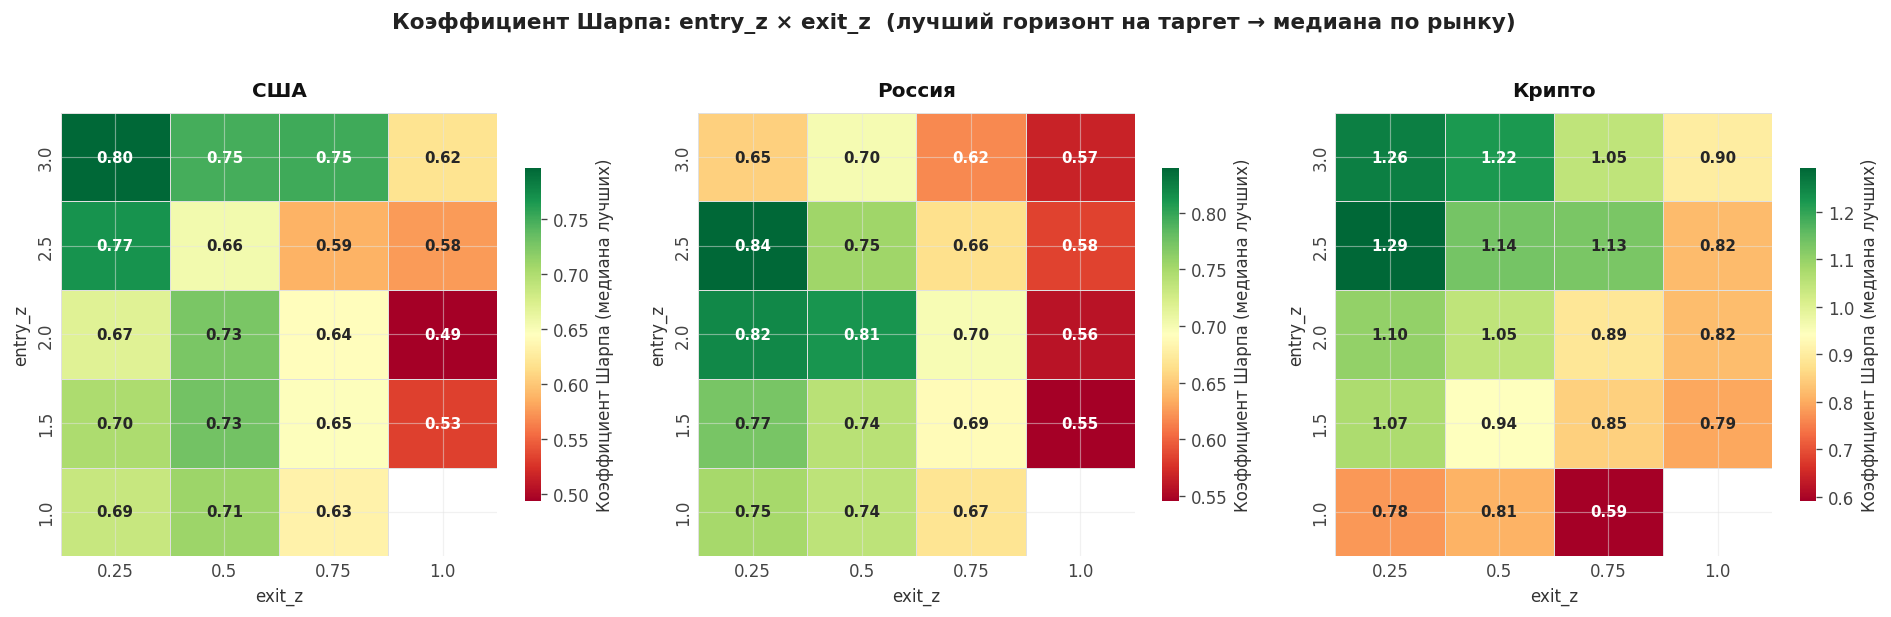

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("white")

for ax, market in zip(axes, MARKETS):
    sub = grid[grid["market"] == market]

    # Шаг 1: для каждого (target, entry_z, exit_z) — лучший Sharpe по train_window/rebalance_freq
    best_ez = (
        sub.groupby(["target", "entry_z", "exit_z"])["sharpe_ratio"]
        .max()
        .reset_index()
    )
    # Шаг 2: медиана лучших результатов по таргетам
    pivot = (
        best_ez.groupby(["entry_z", "exit_z"])["sharpe_ratio"]
        .median()
        .unstack("exit_z")
        .sort_index(ascending=False)
    )

    vmin = pivot.min().min()
    vmax = pivot.max().max()

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax,
        center=(vmin + vmax) / 2,
        linewidths=0.5,
        linecolor="#E0E0E0",
        annot_kws={"size": 9, "weight": "bold"},
        cbar_kws={"shrink": 0.75, "label": "Коэффициент Шарпа (медиана лучших)"},
    )
    ax.set_facecolor("white")
    ax.set_title(f"{MARKET_LABELS[market]}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("exit_z", fontsize=10)
    ax.set_ylabel("entry_z", fontsize=10)
    ax.tick_params(axis="both", which="both", length=0)

fig.suptitle(
    "Коэффициент Шарпа: entry_z × exit_z  (лучший горизонт на таргет → медиана по рынку)",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.show()

### 1b. Карты по отдельным таргетам (лучший Sharpe по train_window + rebalance_frequency)

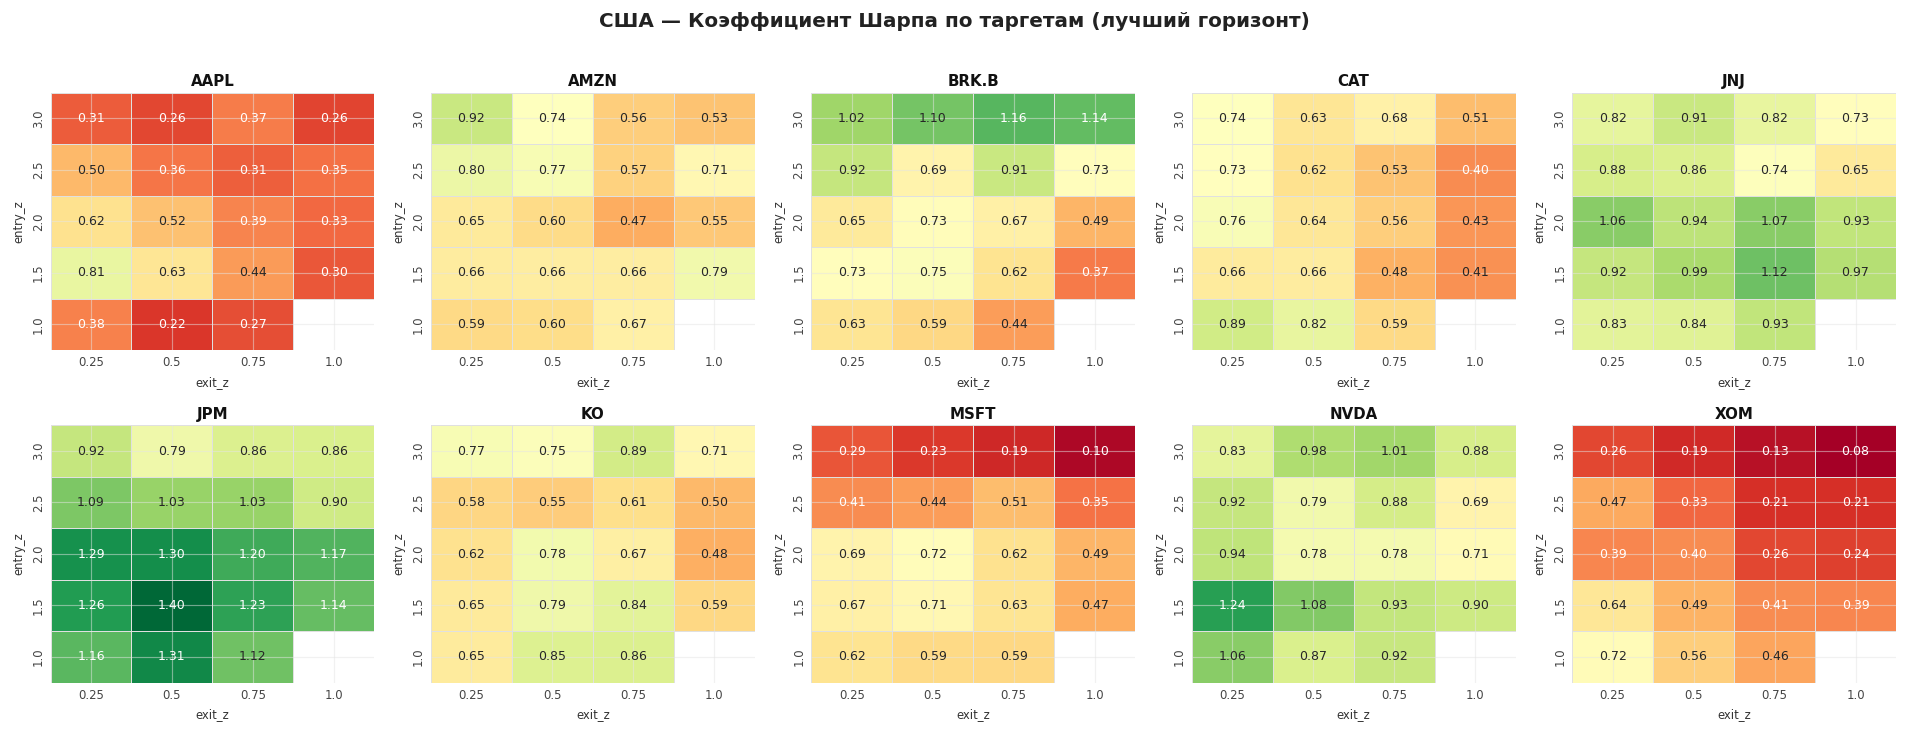

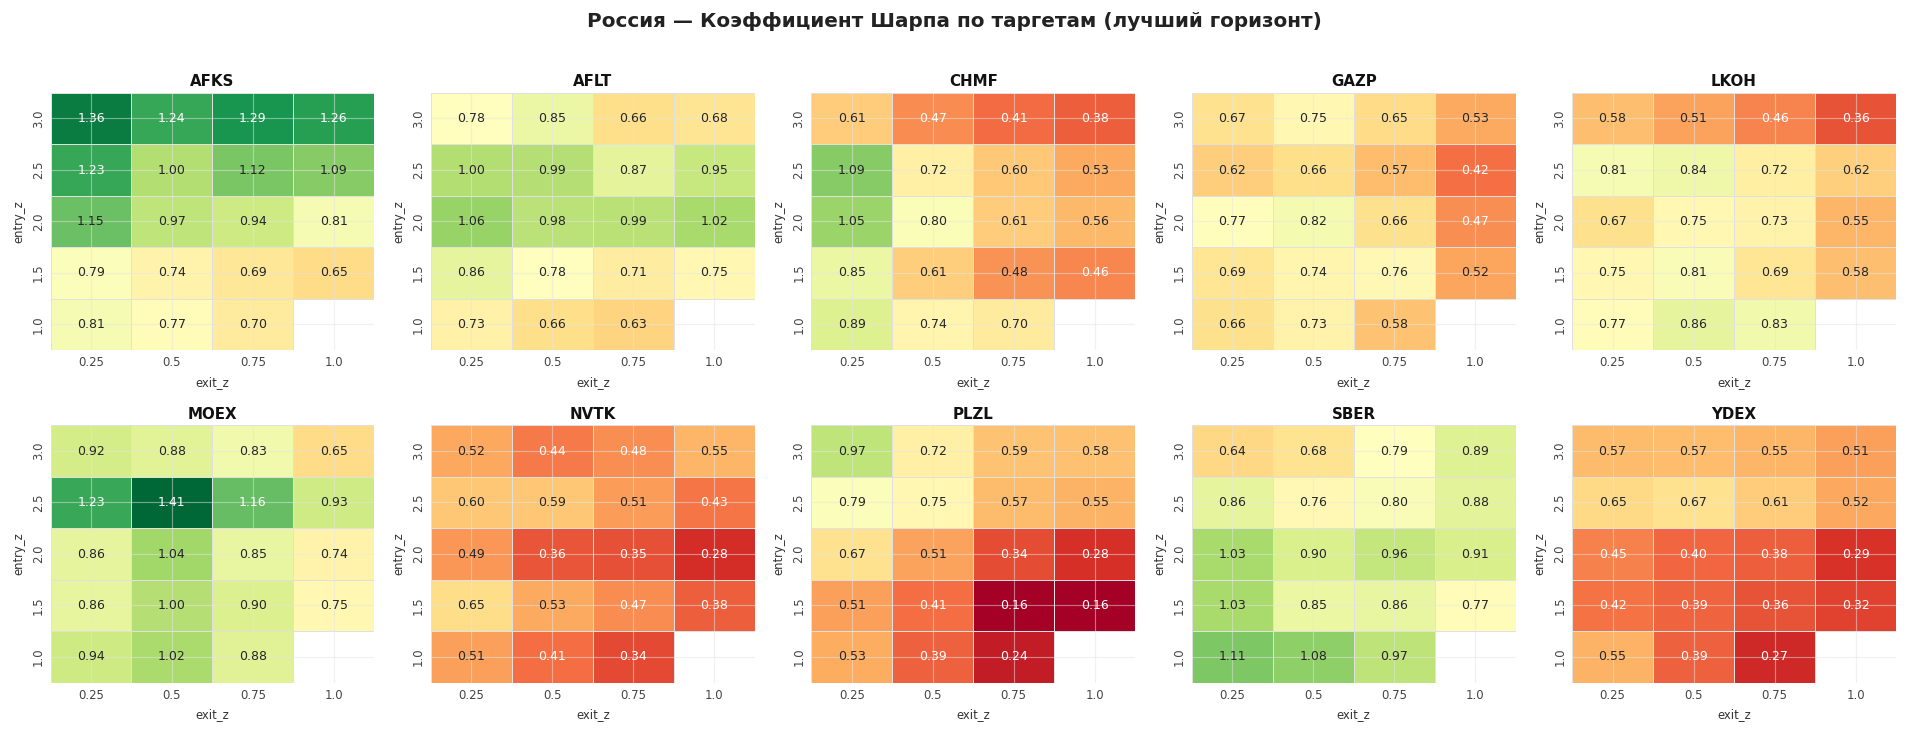

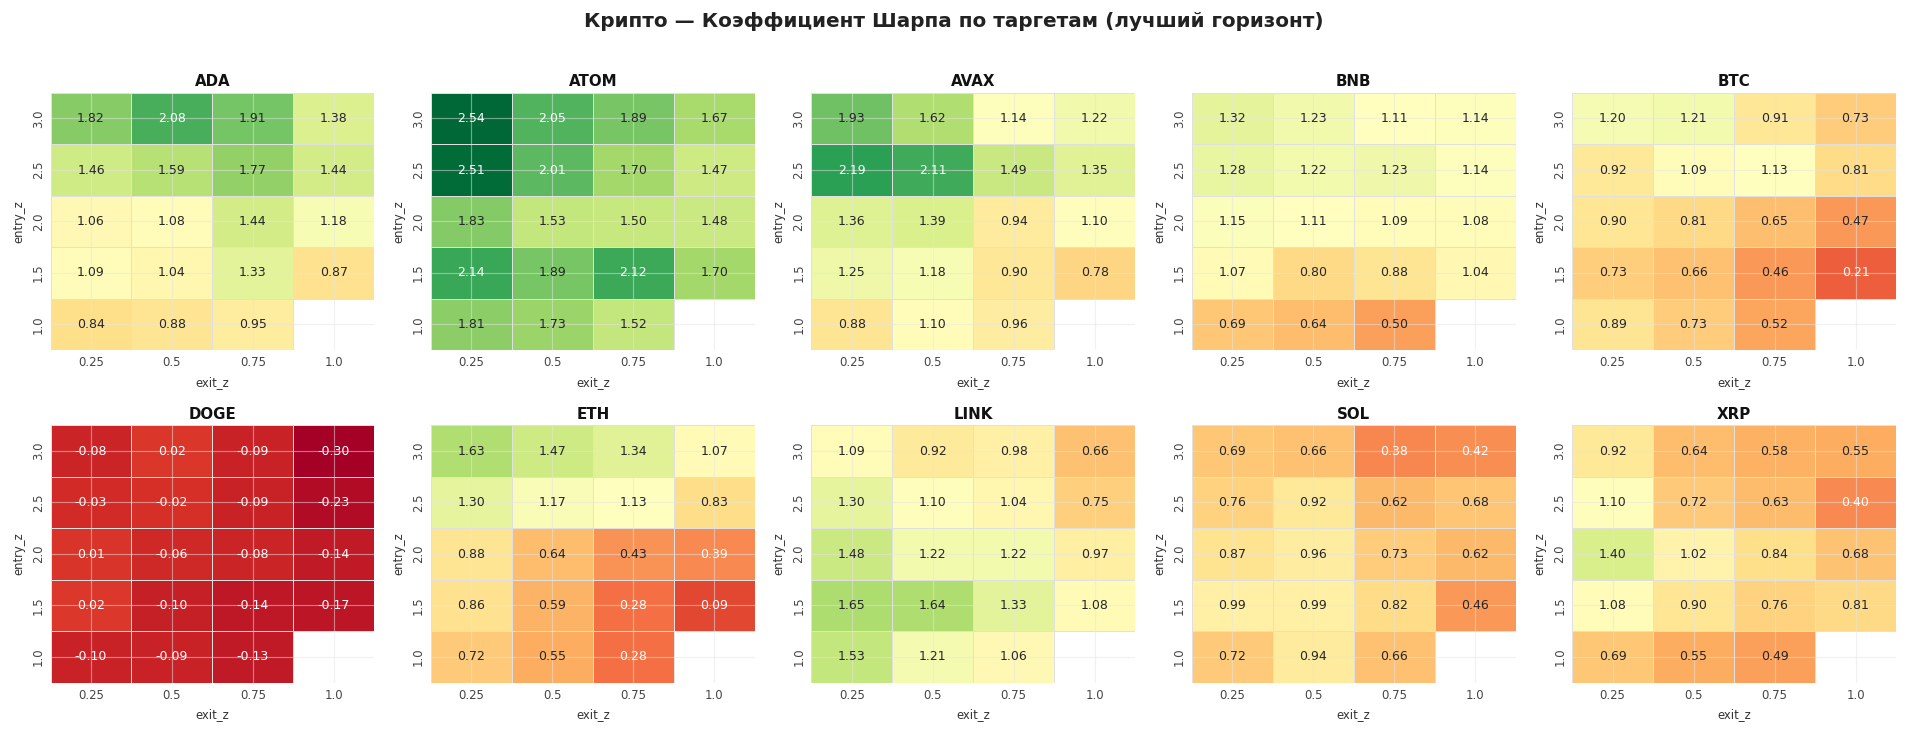

In [16]:
for market in MARKETS:
    sub     = grid[grid["market"] == market]
    targets = sorted(sub["target"].unique())
    n       = len(targets)
    ncols   = 5
    nrows   = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0))
    fig.patch.set_facecolor("white")
    axes_flat = np.array(axes).flatten()

    # Единая шкала: лучший Sharpe по горизонтам для каждого (target, entry_z, exit_z)
    all_best = sub.groupby(["target", "entry_z", "exit_z"])["sharpe_ratio"].max()
    vmin_g = all_best.min()
    vmax_g = all_best.max()

    for i, target in enumerate(targets):
        # Лучший Sharpe по train_window/rebalance_freq для данного таргета
        pivot = (
            sub[sub["target"] == target]
            .groupby(["entry_z", "exit_z"])["sharpe_ratio"]
            .max()
            .unstack("exit_z")
            .sort_index(ascending=False)
        )
        ax = axes_flat[i]
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            vmin=vmin_g,
            vmax=vmax_g,
            center=(vmin_g + vmax_g) / 2,
            linewidths=0.4,
            linecolor="#E0E0E0",
            annot_kws={"size": 7.5},
            cbar=False,
        )
        ax.set_facecolor("white")
        ax.set_title(target, fontsize=9, fontweight="bold", pad=4)
        ax.set_xlabel("exit_z", fontsize=7)
        ax.set_ylabel("entry_z", fontsize=7)
        ax.tick_params(axis="both", labelsize=7, length=0)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        f"{MARKET_LABELS[market]} — Коэффициент Шарпа по таргетам (лучший горизонт)",
        fontsize=12, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()

---
## 2. Прогон пайплайна (лучшие параметры)

Нужен для расчёта R², half-life и rolling correlation — в CSV только агрегаты, а нам нужны временные ряды.

⏳ USA / Russia: ~1–2 мин, Crypto: ~5–10 мин.

In [17]:
import time

best_params = pd.read_csv(BEST_BY_TARGET_PATH)


def prepare_prices(market: str, prices: pd.DataFrame) -> pd.DataFrame:
    if market == "russia":
        return prices.dropna(how="any")
    return prices


def resolve_ticker(prices: pd.DataFrame, target: str) -> str:
    if target in prices.columns:
        return target
    alt = target.replace(".", "-")
    if alt in prices.columns:
        return alt
    raise KeyError(f"Target {target!r} not found in prices")


def reconstruct_run_config(row: pd.Series) -> RunConfig:
    base = load_run_config(str(row["market"]))
    return replace(
        base,
        train_window=int(row["train_window"]),
        rebalance_frequency=int(row["rebalance_frequency"]),
        entry_z=float(row["entry_z"]),
        exit_z=float(row["exit_z"]),
    )


pipeline_results = {}

for market in MARKETS:
    t0 = time.time()
    print(f"\n{'─'*55}")
    print(f"  {market.upper()} — загрузка цен...")
    raw_prices = load_market_prices(market)
    prices     = prepare_prices(market, raw_prices)
    print(f"  Загружено: {prices.shape[0]:,} строк × {prices.shape[1]} активов")

    for _, row in best_params[best_params["market"] == market].iterrows():
        target = row["target"]
        print(f"  [{market}/{target}]... ", end="", flush=True)
        t1 = time.time()
        try:
            ticker    = resolve_ticker(prices, str(target))
            universe  = [s.strip() for s in str(row["universe_assets"]).split(",")]
            rc        = reconstruct_run_config(row)
            result    = run_unified_pipeline(prices, target=ticker, universe=universe, run_config=rc)
            pipeline_results[(market, target)] = result
            m = result.backtest.metrics
            print(f"Sharpe={m.sharpe_ratio:.3f}  Return={m.total_return*100:+.1f}%  [{time.time()-t1:.1f}s]")
        except Exception as exc:
            print(f"ОШИБКА: {exc}")

    print(f"  {market.upper()} готово за {time.time()-t0:.1f}s")

print(f"\n✓ Итого: {len(pipeline_results)} таргетов обработано.")


───────────────────────────────────────────────────────
  USA — загрузка цен...
  Загружено: 2,514 строк × 142 активов
  [usa/AAPL]... Sharpe=0.813  Return=+352.2%  [2.5s]
  [usa/AMZN]... Sharpe=0.915  Return=+470.4%  [0.2s]
  [usa/BRK.B]... Sharpe=1.164  Return=+100.4%  [1.3s]
  [usa/CAT]... Sharpe=0.892  Return=+596.2%  [1.3s]
  [usa/JNJ]... Sharpe=1.118  Return=+252.5%  [2.5s]
  [usa/JPM]... Sharpe=1.402  Return=+603.0%  [2.9s]
  [usa/KO]... Sharpe=0.886  Return=+70.3%  [2.5s]
  [usa/MSFT]... Sharpe=0.724  Return=+203.2%  [0.6s]
  [usa/NVDA]... Sharpe=1.244  Return=+4064.7%  [0.6s]
  [usa/XOM]... Sharpe=0.719  Return=+548.0%  [2.6s]
  USA готово за 17.4s

───────────────────────────────────────────────────────
  RUSSIA — загрузка цен...
  Загружено: 2,959 строк × 26 активов
  [russia/AFKS]... Sharpe=1.356  Return=+1150.0%  [2.6s]
  [russia/AFLT]... Sharpe=1.059  Return=+1585.3%  [2.6s]
  [russia/CHMF]... Sharpe=1.092  Return=+653.8%  [0.7s]
  [russia/GAZP]... Sharpe=0.820  Return=+

---
## 3. Качество репликации

**Метрики** (на дневных лог-доходностях):
- **R²** — доля дисперсии таргета, объяснённая синтетиком.
- **Корреляция Пирсона** — линейная связь доходностей.
- **Tracking Error (TE)** — среднеквадратичное отклонение расхождения доходностей, аннуализированное.
- **PCA Explained Variance** — медиана по ребалансировочным окнам.

Для крипто (часовые данные) доходности агрегируются до дневных перед расчётом.

In [18]:
ROLLING_DAYS = 63  # ~3 месяца в торговых днях


def daily_log_returns(log_prices: pd.Series, annualization_factor: float) -> pd.Series:
    """Дневные лог-доходности. Для часовых данных агрегируем до дня."""
    ret = log_prices.diff().dropna()
    if annualization_factor > 300:  # крипто: часовые данные
        ret = ret.resample("D").sum().dropna()
    return ret


def compute_replication_quality(result) -> dict:
    af  = result.run_config.annualization_factor
    tgt = daily_log_returns(result.replication.target_log_prices, af)
    syn = daily_log_returns(result.replication.synthetic_log_prices, af)
    tgt, syn = tgt.align(syn, join="inner")
    tgt, syn = tgt.dropna(), syn.dropna()
    tgt, syn = tgt.align(syn, join="inner")

    if len(tgt) < 10:
        return {}

    correlation    = float(tgt.corr(syn))
    r_squared      = correlation ** 2
    diff           = tgt - syn
    tracking_error = float(diff.std() * np.sqrt(252))  # всегда в годовых

    meta = result.replication.metadata
    ok   = meta[meta["segment_status"] == "ok"]
    pca_ev = float(ok["explained_variance"].median()) if len(ok) > 0 else np.nan

    return {
        "n_obs":          len(tgt),
        "correlation":    correlation,
        "r_squared":      r_squared,
        "tracking_error": tracking_error,
        "pca_ev":         pca_ev,
        "tgt_ret":        tgt,
        "syn_ret":        syn,
    }

### 3a. Сводные таблицы по рынкам

In [19]:
replication_quality = {}
for key, result in pipeline_results.items():
    replication_quality[key] = compute_replication_quality(result)


def replication_table(market: str):
    rows = []
    for (mkt, target), rq in sorted(replication_quality.items(), key=lambda x: -x[1].get("r_squared", 0)):
        if mkt != market or not rq:
            continue
        rows.append({
            "Актив":               target,
            "R²":                  rq["r_squared"],
            "Корреляция":          rq["correlation"],
            "Tracking Error (г.)": rq["tracking_error"],
            "PCA Expl. Var.": rq["pca_ev"],
            "Наблюдений (дней)":   rq["n_obs"],
        })
    df = pd.DataFrame(rows)
    df.index = range(1, len(df) + 1)
    return (
        df.style
        .format({
            "R²":                  "{:.3f}",
            "Корреляция":          "{:.3f}",
            "Tracking Error (г.)": "{:.4f}",
            "PCA Expl. Var.": "{:.1%}",
        })
        .background_gradient(subset=["R²", "Корреляция"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Tracking Error (г.)"], cmap="RdYlGn_r")
        .set_table_styles(TABLE_STYLES)
        .set_caption(f"{MARKET_LABELS[market]} — Качество репликации")
    )


for market in MARKETS:
    display(replication_table(market))
    print()

,Актив,R²,Корреляция,Tracking Error (г.),PCA Expl. Var.,Наблюдений (дней)
1,MSFT,0.453,0.673,0.2346,83.5%,2261
2,AAPL,0.433,0.658,0.2626,83.9%,2261
3,JPM,0.365,0.605,0.2385,84.0%,2261
4,KO,0.350,0.591,0.1567,83.9%,2261
5,NVDA,0.337,0.580,0.4964,83.5%,2261
6,BRK.B,0.324,0.569,0.1722,84.0%,2261
7,AMZN,0.209,0.457,0.3621,83.9%,2261
8,CAT,0.173,0.416,0.3103,83.7%,2261
9,JNJ,0.170,0.412,0.1822,83.8%,2261
10,XOM,0.032,0.178,0.3757,83.8%,2261


,Актив,R²,Корреляция,Tracking Error (г.),PCA Expl. Var.,Наблюдений (дней)
1,SBER,0.428,0.654,0.3117,84.4%,2706
2,LKOH,0.301,0.548,0.2665,84.4%,2706
3,AFKS,0.242,0.492,0.4076,84.2%,2706
4,YDEX,0.239,0.489,0.4207,84.4%,2706
5,CHMF,0.238,0.488,0.3176,84.3%,2706
6,MOEX,0.225,0.474,0.2800,84.2%,2706
7,GAZP,0.204,0.452,0.3414,84.5%,2706
8,NVTK,0.168,0.410,0.3448,84.4%,2706
9,AFLT,0.161,0.401,0.3904,84.2%,2706
10,PLZL,0.028,0.168,0.4014,84.0%,2706


,Актив,R²,Корреляция,Tracking Error (г.),PCA Expl. Var.,Наблюдений (дней)
1,ETH,0.690,0.831,0.4196,85.9%,2132
2,LINK,0.637,0.798,0.5461,85.9%,2132
3,BTC,0.580,0.761,0.3566,85.8%,2132
4,ADA,0.565,0.752,0.5957,85.9%,2132
5,BNB,0.493,0.702,0.5351,86.1%,2132
6,ATOM,0.470,0.685,0.6821,86.0%,2132
7,AVAX,0.453,0.673,0.8037,85.9%,1912
8,XRP,0.347,0.589,0.8166,86.0%,2132
9,SOL,0.307,0.554,0.9103,85.7%,1954
10,DOGE,0.146,0.382,1.2518,86.0%,2132


### 3b. Скользящая корреляция доходностей (окно 63 дня)

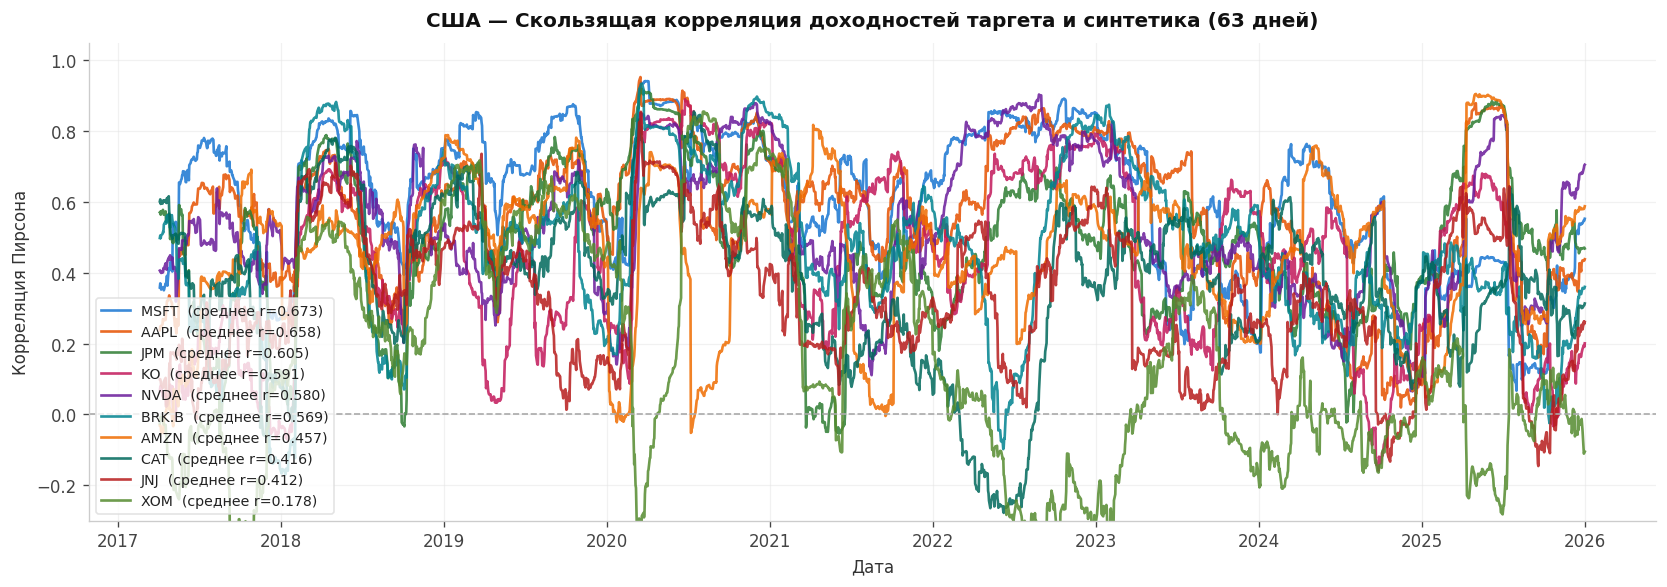

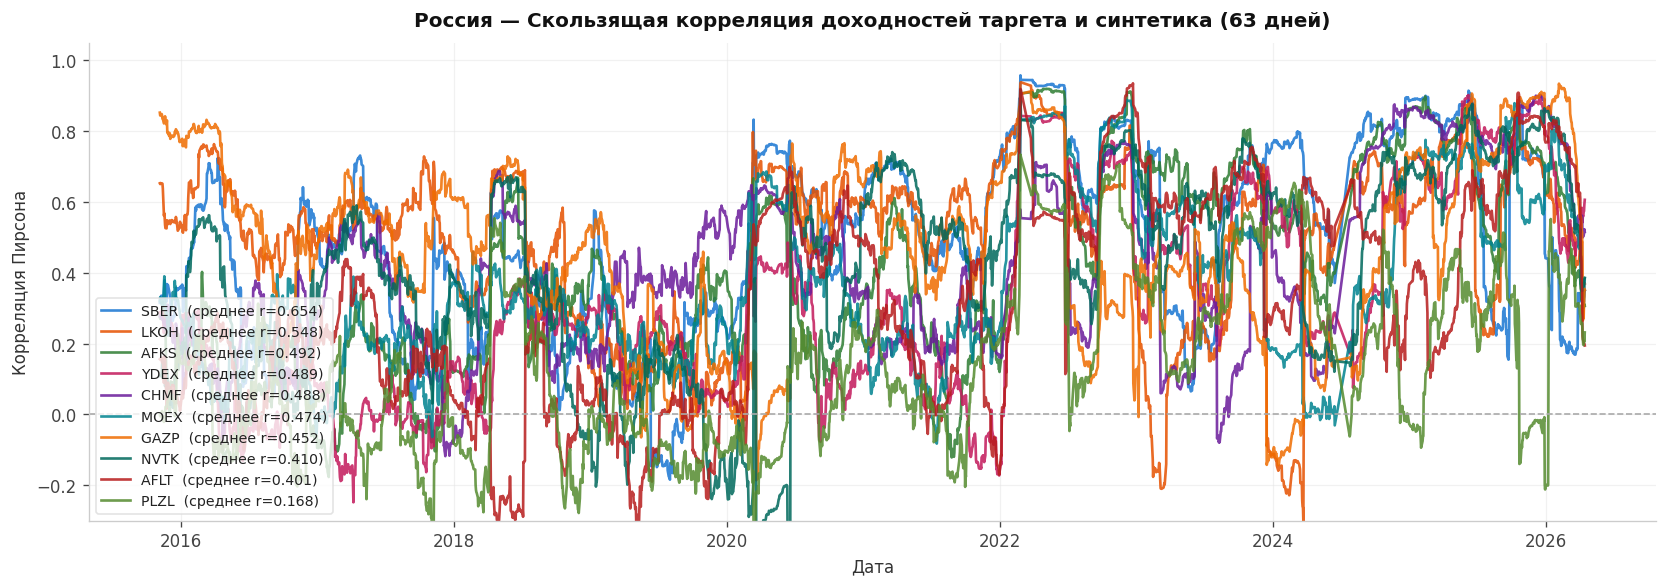

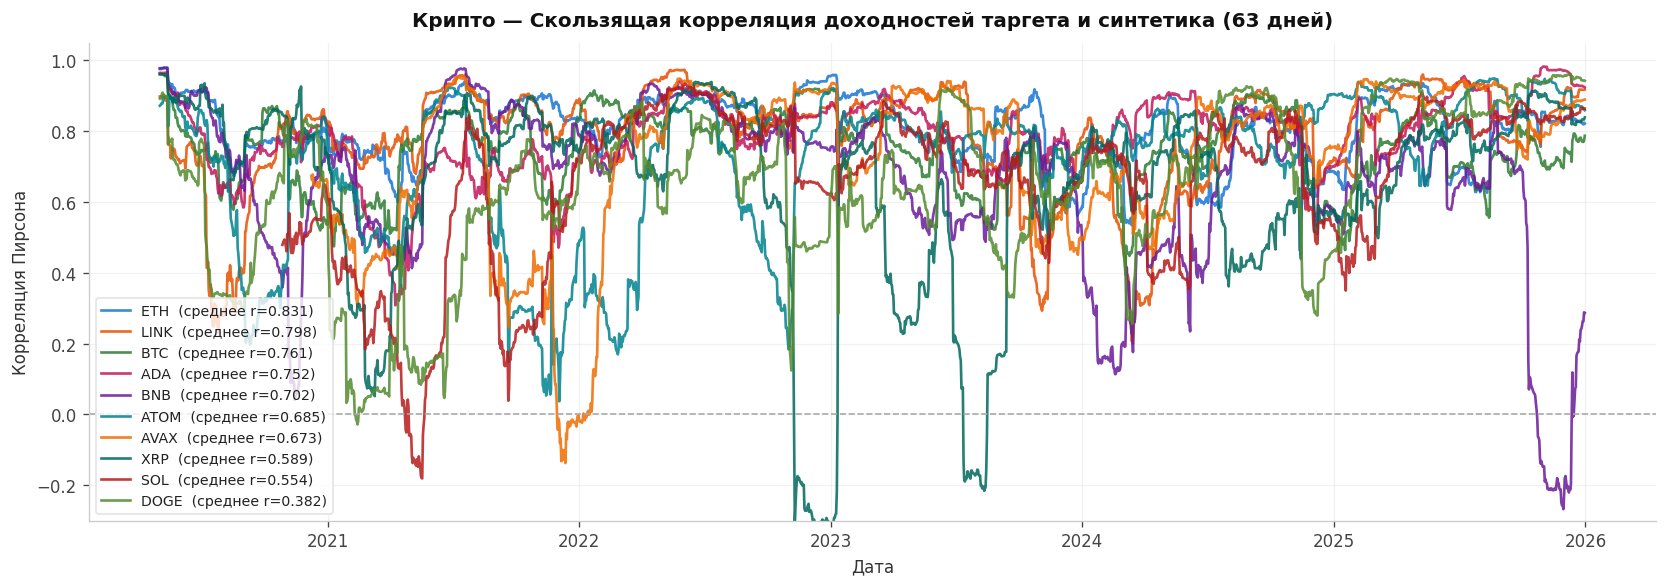

In [20]:
for market in MARKETS:
    items = [(k, v) for k, v in replication_quality.items() if k[0] == market and v]
    if not items:
        continue

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for i, ((mkt, target), rq) in enumerate(sorted(items, key=lambda x: -x[1].get("correlation", 0))):
        tgt = rq["tgt_ret"]
        syn = rq["syn_ret"]
        combined = pd.DataFrame({"tgt": tgt, "syn": syn}).dropna()
        rolling_corr = combined["tgt"].rolling(ROLLING_DAYS).corr(combined["syn"])
        mean_corr = float(rq["correlation"])
        ax.plot(
            rolling_corr.index, rolling_corr,
            label=f"{target}  (среднее r={mean_corr:.3f})",
            linewidth=1.6,
            color=PALETTE[i % len(PALETTE)],
            alpha=0.85,
        )

    ax.axhline(0, color="#AAAAAA", linestyle="--", linewidth=1.0)
    ax.set_title(
        f"{MARKET_LABELS[market]} — Скользящая корреляция доходностей таргета и синтетика ({ROLLING_DAYS} дней)",
        fontsize=12, fontweight="bold", pad=10,
    )
    ax.set_ylabel("Корреляция Пирсона", fontsize=10)
    ax.set_xlabel("Дата", fontsize=10)
    ax.set_ylim(-0.3, 1.05)
    legend = ax.legend(fontsize=8.5, loc="lower left", frameon=True)
    legend.get_frame().set_facecolor("white")
    fig.tight_layout()
    plt.show()

---
## 4. Half-Life of Mean Reversion

**Модель Орнштейна-Уленбека:** $\Delta S_t = \alpha + \beta \cdot S_{t-1} + \varepsilon_t$

- $\beta < 0$ — спред стационарен (mean-reverting).
- $\text{Half-life} = -\ln(2) / \beta$ в барах → конвертируем в **торговые дни**.
- **ADF p-value** — дополнительная проверка стационарности (чем меньше, тем лучше).

In [25]:
def compute_halflife(spread: pd.Series, bars_per_day: float = 1.0) -> dict:
    s = spread.dropna()
    if len(s) < 30:
        return {"half_life_days": np.nan, "beta": np.nan, "adf_stat": np.nan, "adf_pvalue": np.nan}

    delta  = s.diff().dropna()
    lagged = s.shift(1).dropna()
    lagged, delta = lagged.align(delta, join="inner")

    X   = sm.add_constant(lagged)
    ols = sm.OLS(delta, X).fit()
    beta = float(ols.params.iloc[-1])

    half_life_bars = -np.log(2) / beta if beta < 0 else np.nan
    half_life_days = half_life_bars / bars_per_day if not np.isnan(half_life_bars) else np.nan

    adf = adfuller(s, maxlag=1, regression="c", autolag=None)

    return {
        "half_life_days": half_life_days,
        "beta":           beta,
        "adf_stat":       float(adf[0]),
        "adf_pvalue":     float(adf[1]),
    }


halflife_results = {}
for (market, target), result in pipeline_results.items():
    af = result.run_config.annualization_factor
    bars_per_day = af / 252  # 1 для дневных, 24 для часовых
    spread = result.backtest.spread
    halflife_results[(market, target)] = compute_halflife(spread, bars_per_day=bars_per_day)

print("Half-life рассчитан для", len(halflife_results), "таргетов.")

Half-life рассчитан для 30 таргетов.


### 4a. Сводные таблицы half-life по рынкам

In [26]:
def halflife_table(market: str):
    rows = []
    for (mkt, target), hl in sorted(halflife_results.items(), key=lambda x: x[1].get("half_life_days", np.inf)):
        if mkt != market:
            continue
        sharpe = pipeline_results[(mkt, target)].backtest.metrics.sharpe_ratio
        rows.append({
            "Актив":              target,
            "Half-Life (дней)":  hl["half_life_days"],
            "β (ОУ)":            hl["beta"],
            "ADF stat":          hl["adf_stat"],
            "ADF p-value":       hl["adf_pvalue"],
            "Коэффициент Шарпа": sharpe,
        })
    df = pd.DataFrame(rows)
    df.index = range(1, len(df) + 1)
    return (
        df.style
        .format({
            "Half-Life (дней)":  "{:.1f}",
            "β (ОУ)":            "{:.5f}",
            "ADF stat":          "{:.3f}",
            "ADF p-value":       "{:.4f}",
            "Коэффициент Шарпа": "{:.3f}",
        })
        .background_gradient(subset=["Half-Life (дней)"], cmap="RdYlGn_r", vmin=1)
        .background_gradient(subset=["Коэффициент Шарпа"], cmap="RdYlGn")
        .set_table_styles(TABLE_STYLES)
        .set_caption(f"{MARKET_LABELS[market]} — Half-Life спреда")
    )


for market in MARKETS:
    display(halflife_table(market))
    print()

,Актив,Half-Life (дней),β (ОУ),ADF stat,ADF p-value,Коэффициент Шарпа
1,XOM,13.1,-0.05309,-7.272,0.0000,0.719
2,JNJ,18.2,-0.03815,-6.584,0.0000,1.118
3,AAPL,18.6,-0.03728,-5.769,0.0000,0.813
4,KO,19.9,-0.03475,-6.274,0.0000,0.886
5,JPM,21.1,-0.03290,-6.068,0.0000,1.402
6,MSFT,21.4,-0.03242,-5.936,0.0000,0.724
7,NVDA,21.9,-0.03168,-6.072,0.0000,1.244
8,BRK.B,22.9,-0.03022,-5.897,0.0000,1.164
9,CAT,23.2,-0.02983,-6.021,0.0000,0.892
10,AMZN,33.0,-0.02098,-4.940,0.0000,0.915


,Актив,Half-Life (дней),β (ОУ),ADF stat,ADF p-value,Коэффициент Шарпа
1,NVTK,17.0,-0.04083,-7.029,0.0000,0.653
2,AFKS,19.3,-0.03599,-7.341,0.0000,1.356
3,YDEX,19.4,-0.03571,-6.795,0.0000,0.671
4,AFLT,19.9,-0.03488,-7.307,0.0000,1.059
5,LKOH,20.6,-0.03361,-6.913,0.0000,0.865
6,MOEX,21.0,-0.03300,-6.696,0.0000,1.407
7,SBER,22.4,-0.03096,-6.495,0.0000,1.111
8,GAZP,24.3,-0.02852,-6.736,0.0000,0.820
9,CHMF,25.0,-0.02772,-6.127,0.0000,1.092
10,PLZL,28.6,-0.02424,-5.949,0.0000,0.970


,Актив,Half-Life (дней),β (ОУ),ADF stat,ADF p-value,Коэффициент Шарпа
1,ADA,3.7,-0.00537,-11.227,0.0000,2.076
2,ATOM,3.8,-0.00527,-11.434,0.0000,2.539
3,XRP,3.9,-0.00510,-11.121,0.0000,1.405
4,SOL,4.0,-0.00503,-10.460,0.0000,0.986
5,BTC,4.4,-0.00458,-10.578,0.0000,1.210
6,DOGE,4.4,-0.00453,-10.500,0.0000,0.024
7,LINK,4.5,-0.00442,-10.301,0.0000,1.651
8,AVAX,4.6,-0.00432,-9.562,0.0000,2.187
9,ETH,5.0,-0.00397,-9.844,0.0000,1.628
10,BNB,5.3,-0.00377,-9.570,0.0000,1.319


### 4b. Bar-chart: Half-Life по таргетам

Цвет бара — градиент по величине half-life: **зелёный = короткий (быстрый возврат)**, красный = длинный (медленный). ADF p-value указан для справки.

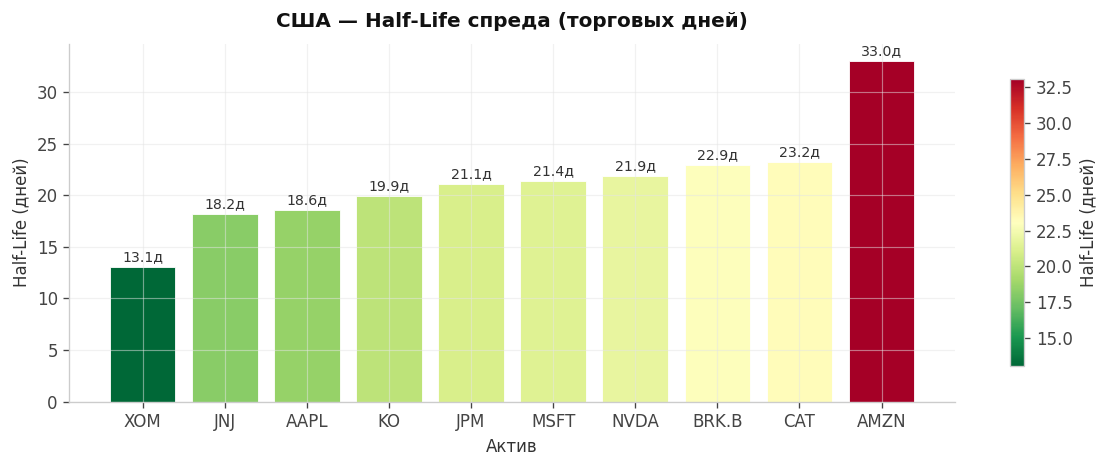

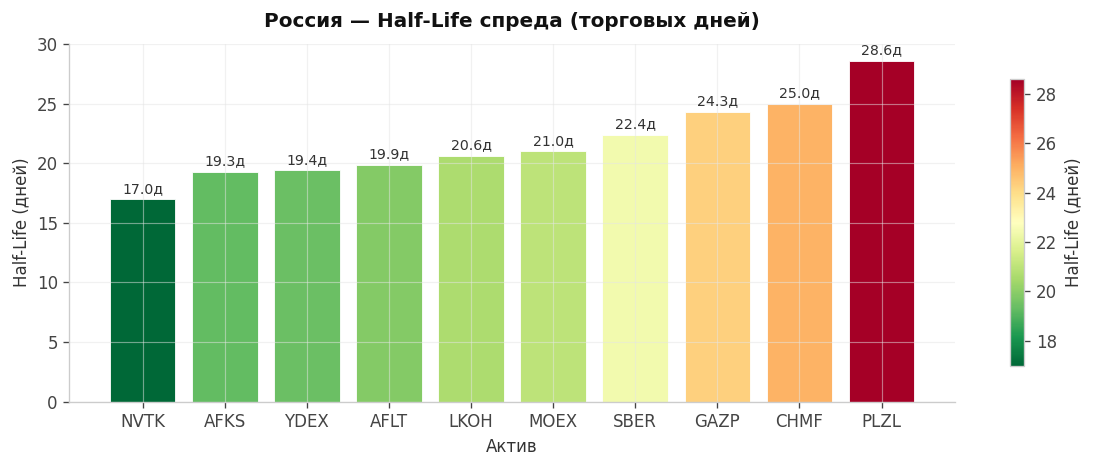

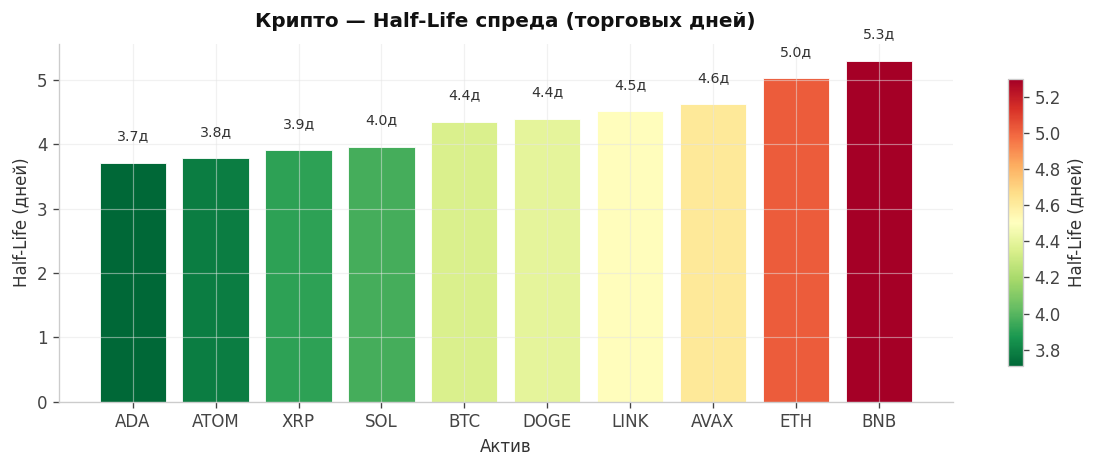

In [28]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

for market in MARKETS:
    items = [
        (target, hl)
        for (mkt, target), hl in halflife_results.items()
        if mkt == market and not np.isnan(hl.get("half_life_days", np.nan))
    ]
    if not items:
        continue
    items_sorted = sorted(items, key=lambda x: x[1]["half_life_days"])
    labels  = [x[0] for x in items_sorted]
    hl_vals = [x[1]["half_life_days"] for x in items_sorted]

    norm       = mcolors.Normalize(vmin=min(hl_vals), vmax=max(hl_vals))
    cmap_hl    = cm.RdYlGn_r
    bar_colors = [cmap_hl(norm(v)) for v in hl_vals]

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    bars = ax.bar(labels, hl_vals, color=bar_colors, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, hl_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}д",
            ha="center", va="bottom", fontsize=8.5, color="#333333",
        )

    sm = cm.ScalarMappable(cmap=cmap_hl, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.8, label="Half-Life (дней)")

    ax.set_title(
        f"{MARKET_LABELS[market]} — Half-Life спреда (торговых дней)",
        fontsize=12, fontweight="bold", pad=10,
    )
    ax.set_ylabel("Half-Life (дней)", fontsize=10)
    ax.set_xlabel("Актив", fontsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
    fig.tight_layout()
    plt.show()

---
## 5. Сводный дашборд: Sharpe vs Half-Life vs R²

Scatter-plot для всех таргетов всех рынков:
- **X** — Half-Life (чем меньше, тем быстрее возврат).
- **Y** — Коэффициент Шарпа.
- **Размер точки** — R² (качество репликации).
- **Цвет** — рынок.

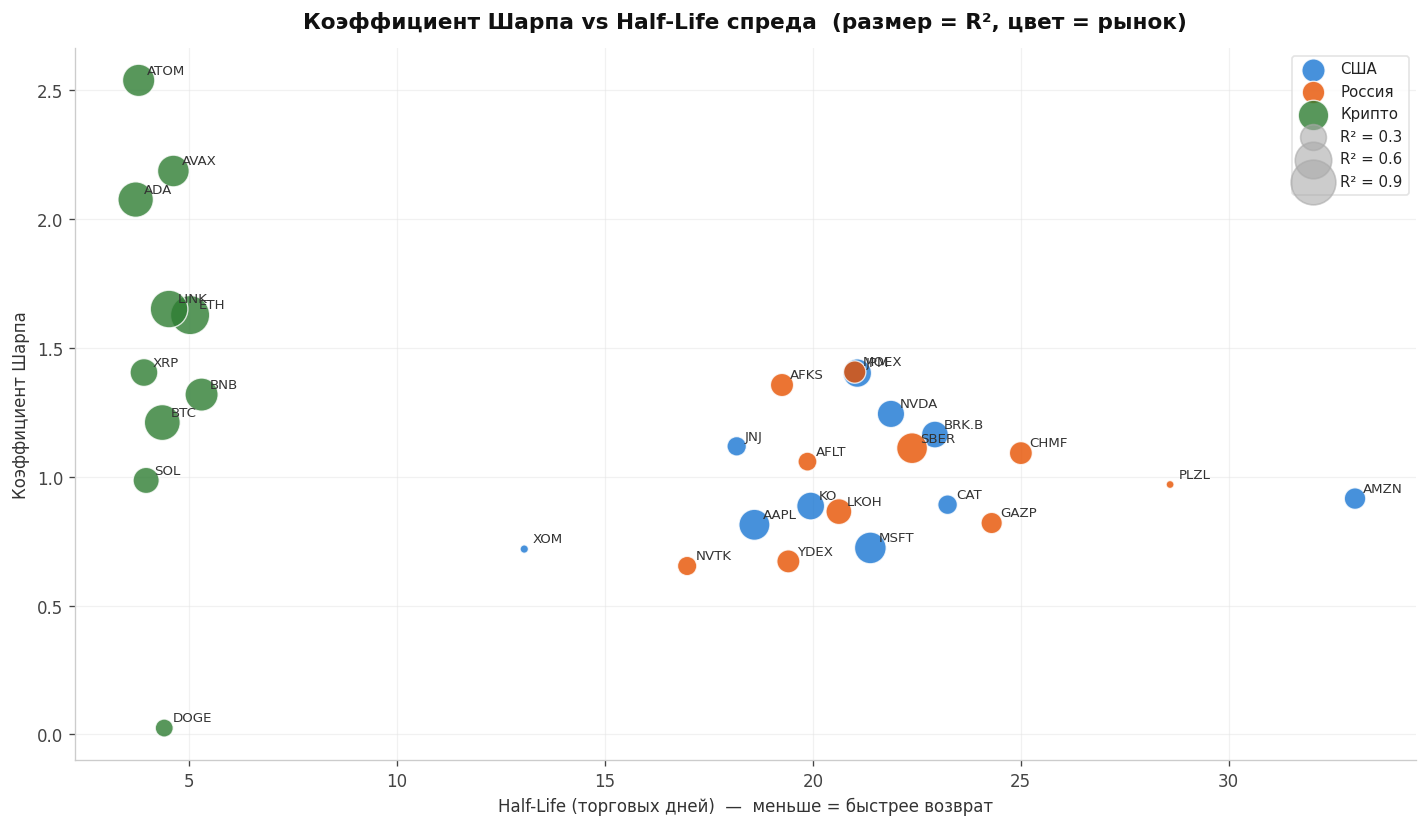

In [24]:
scatter_rows = []
for (market, target), result in pipeline_results.items():
    hl = halflife_results.get((market, target), {})
    rq = replication_quality.get((market, target), {})
    if not hl or not rq:
        continue
    hl_days = hl.get("half_life_days", np.nan)
    r2      = rq.get("r_squared", np.nan)
    sharpe  = result.backtest.metrics.sharpe_ratio
    if np.isnan(hl_days) or np.isnan(r2):
        continue
    scatter_rows.append({
        "market": market, "target": target,
        "half_life": hl_days, "sharpe": sharpe, "r2": r2,
        "adf_pvalue": hl.get("adf_pvalue", np.nan),
    })

sdf = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for market in MARKETS:
    sub = sdf[sdf["market"] == market]
    sc  = ax.scatter(
        sub["half_life"], sub["sharpe"],
        s=sub["r2"] * 800,
        c=MARKET_COLORS[market],
        alpha=0.80,
        edgecolors="white", linewidth=0.8,
        label=MARKET_LABELS[market],
        zorder=3,
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row["target"],
            (row["half_life"], row["sharpe"]),
            xytext=(5, 4), textcoords="offset points",
            fontsize=8, color="#333333",
        )

# Легенда для размера точек
for r2_val in [0.3, 0.6, 0.9]:
    ax.scatter([], [], s=r2_val * 800, c="#AAAAAA", alpha=0.6, label=f"R² = {r2_val:.1f}")

ax.set_title(
    "Коэффициент Шарпа vs Half-Life спреда  (размер = R², цвет = рынок)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Half-Life (торговых дней)  —  меньше = быстрее возврат", fontsize=10)
ax.set_ylabel("Коэффициент Шарпа", fontsize=10)
legend = ax.legend(fontsize=9, frameon=True, loc="upper right")
legend.get_frame().set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
fig.tight_layout()
plt.show()